In [41]:
import numpy as np
import pandas as pd
import os,sys
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 18})
plt.rcParams['figure.figsize'] = (10, 6)

cwd = os.getcwd() #grabs current working directory

testfolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'TEMP' / '2026-08-forTCurtis')
inputfolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'TEMP')
baselinesfolder = str(Path().resolve().parent.parent /'PV_ICE' / 'baselines')
supportMatfolder = str(Path().resolve().parent.parent / 'PV_ICE' / 'baselines' / 'SupportingMaterial')

if not os.path.exists(testfolder):
    os.makedirs(testfolder)

In [42]:
#creating scenarios for identical power of multiple technologies
scennames = ['base'] #
MATERIALS = ['glass','silver','silicon', 'copper', 'aluminium_frames', 'encapsulant', 'backsheet']
moduleFile_m = os.path.join(baselinesfolder, 'baseline_modules_mass_World.csv')
#moduleFile_e = os.path.join(baselinesfolder, 'baseline_modules_energy.csv')
#moduledeploy = pd.read_csv(os.path.join(supportMatfolder, 'output_Global_SiPV_installs.csv'))

In [43]:
#load in a baseline and materials for modification
import PV_ICE

PV_ICE.__version__

'0.4.3'

In [44]:
sim1 = PV_ICE.Simulation(name='sim1', path=testfolder)
for scen in scennames:
    sim1.createScenario(name=scen, massmodulefile=moduleFile_m)
    for mat in range (0, len(MATERIALS)):
        matbaseline_m = os.path.join(baselinesfolder,'baseline_material_mass_'+MATERIALS[mat]+'.csv')
        #matbaseline_e = os.path.join(baselinesfolder,'baseline_material_energy_'+MATERIALS[mat]+'.csv')
        sim1.scenario[scen].addMaterial(MATERIALS[mat], massmatfile=matbaseline_m)#, energymatfile=matbaseline_e)

path = C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_ICE\PV_ICE\TEMP\2026-08-forTCurtis
Baseline folder directed to default:  C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\baselines
File not found, check path to folder if passed is correct or that baseline folder is correct C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_ICE\PV_ICE\baselines\baseline_modules_mass_World.csv


KeyError: 'base'

In [45]:
#Lifetime and Degradation
#values taken from lifetime vs recycling paper
#degradation rate:
#sim1.modifyScenario('test', 'mod_degradation',0.2, start_year=2000) 
#sim1.modifyScenario('test', 'mod_lifetime', 50, start_year=2000) 
#sim1.modifyScenario('test', 'new_Installed_Capacity_[MW]', 0.0, start_year=1995) 
#sim1.modifyScenario('test', 'mod_eff', 17.0, start_year=1995) 

#sim1.scenMod_perfectRecycling()
sim1.scenMod_noCircularity()

In [46]:
#trim to start in 2000, this trims module and materials
#had to specify and end year, cannot use to extend
sim1.trim_Years(startYear=2000, endYear=2100)

IndexError: list index out of range

In [ ]:
sim1.scenario['base'].dataIn_m

In [ ]:
sim1.calculateMassFlow(scenarios='base')

In [ ]:
sim1.scenario['base'].dataOut_m.keys()

In [ ]:
plt.plot(sim1.scenario['base'].dataIn_m['year'], sim1.scenario['base'].dataOut_m['Effective_Capacity_[W]']/1e12)
plt.ylim(0,)
plt.ylabel('Effective capacity in TW')
plt.title('Effective capacity in TW')
#plt.plot(sim1.scenario['base'].dataIn_m['new_Installed_Capacity_[MW]'])

Good, this deployment aligns with Haegel et al 2023

In [47]:
sim1_annual, sim1_cumu = sim1.aggregateResults()

IndexError: list index out of range

In [ ]:
#MASS
sim1_cumu.filter(like='WasteEOL')

Text(0, 0.5, 'Module EoL Mass [Million metric tonnes]')

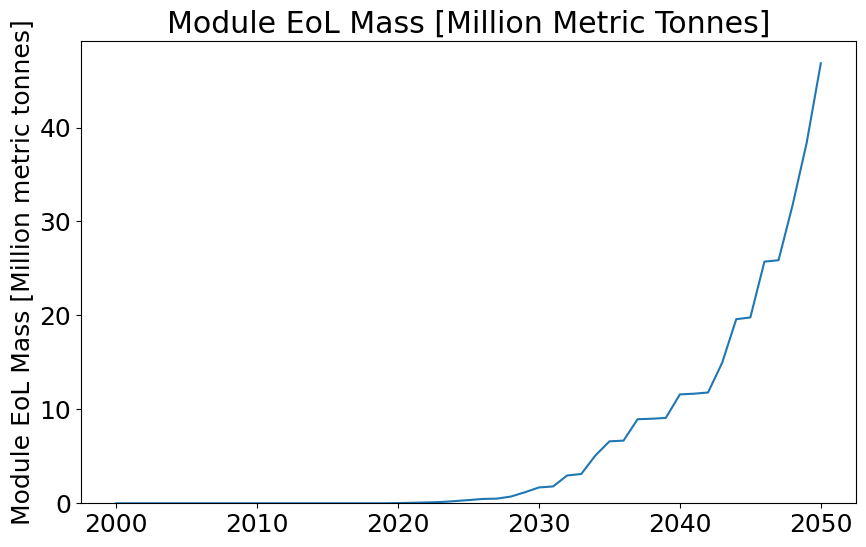

In [48]:
eol_module_tonnes = sim1_cumu.loc[:2050,'WasteEOL_Module_sim1_base_[Tonnes]']
plt.plot(eol_module_tonnes/1e6)
plt.ylim(0,)
plt.title('Module EoL Mass [Million Metric Tonnes]')
plt.ylabel('Module EoL Mass [Million metric tonnes]')

In [49]:
eol_cumu_all = sim1_cumu.filter(like='WasteEOL')
eol_cumu_all_mats_2050 = eol_cumu_all.loc[:2050].iloc[:,:7]
#eol_cumu_all_mats_2050

In [50]:
eol_cumu_all_mats_2050.columns

Index(['WasteEOL_glass_sim1_base_[Tonnes]',
       'WasteEOL_silver_sim1_base_[Tonnes]',
       'WasteEOL_silicon_sim1_base_[Tonnes]',
       'WasteEOL_copper_sim1_base_[Tonnes]',
       'WasteEOL_aluminium_frames_sim1_base_[Tonnes]',
       'WasteEOL_encapsulant_sim1_base_[Tonnes]',
       'WasteEOL_backsheet_sim1_base_[Tonnes]'],
      dtype='object')

(2000.0, 2051.0)

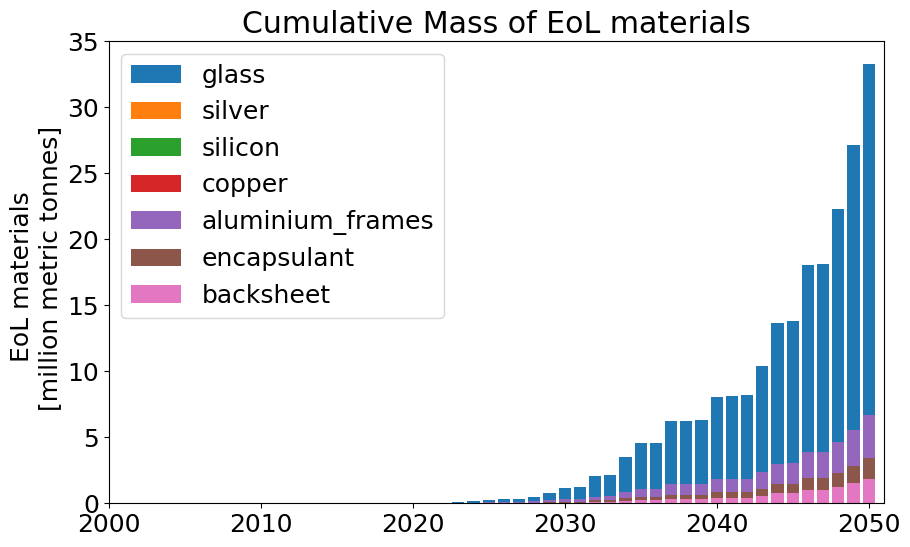

In [51]:
for mat in eol_cumu_all_mats_2050.columns:
    plt.bar(eol_cumu_all_mats_2050.index, eol_cumu_all_mats_2050[mat]/1e6)
plt.legend(MATERIALS)
plt.ylabel('EoL materials \n [million metric tonnes]')
plt.title('Cumulative Mass of EoL materials')
plt.ylim(0,35)
plt.xlim(2000,2051)

In [52]:
eos_cumu_mats_milltonne = eol_cumu_all_mats_2050/1e6
eos_cumu_mats_milltonne.to_csv(os.path.join(testfolder, 'output_cumu_mats_milltonne.csv'))

## in number of modules and GWs

In [53]:
sim1.scenario['base'].dataOut_m.keys()

KeyError: 'base'

In [ ]:
modulearea_eol_millionm2 = sim1.scenario['base'].dataOut_m['Yearly_Sum_Area_atEOL'].cumsum()/1e6

In [ ]:
plt.bar(sim1.scenario['base'].dataIn_m['year'], modulearea_eol_millionm2)
plt.ylim(0,)
plt.title('Cumulative Area at EoL in 1e6 m2')
plt.ylabel('million meters^2')

In [ ]:
eol_modules_smaller = sim1.scenario['base'].dataOut_m['Yearly_Sum_Area_atEOL'].cumsum()/1.6
eol_modules_larger = sim1.scenario['base'].dataOut_m['Yearly_Sum_Area_atEOL'].cumsum()/2.75
df_modules = pd.concat([eol_modules_smaller, eol_modules_larger], axis=1)
#, columns=
df_modules.columns = ['Cumulative Modules 1.6m2','Cumulative Modules 2.75m2']
df_modules.index = sim1.scenario['base'].dataIn_m['year']
df_modules

In [ ]:
cumu_power_eol = pd.Series(sim1.scenario['base'].dataOut_m['Yearly_Sum_Power_atEOL'].cumsum()/1e9)#GW
cumu_power_eol.index = sim1.scenario['base'].dataIn_m['year']
df_modules['Cumulative Power at EoL [GW]'] = cumu_power_eol

In [54]:
df_modules.to_csv(os.path.join(testfolder, 'output_modules_power_cumuEoL.csv'))

# High Degradation/Early Retirement Scenario

create baseline input files for PV Fleets degradation spread, to examine a higher failure scenario.

In [55]:
fleets_deg_rates = pd.read_csv(os.path.join(supportMatfolder, 'PVFleets_Degradation_Data.csv'))
df_baseline_module_world = pd.read_csv(moduleFile_m)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\hmirletz\\Documents\\GitHub\\PV_ICE\\PV_ICE\\PV_ICE\\baselines\\SupportingMaterial\\PVFleets_Degradation_Data.csv'

In [ ]:
deg_baselines_filenames = [] # for later use
deg_rate_log = [] #for later use

for row in fleets_deg_rates.index:
    df_module_world_cohort = df_baseline_module_world.copy() #make copy df
    
    deg_rate = fleets_deg_rates.loc[row]['Degradation Rate']*-1 #extract deg rate, fix negative
    cohort_percent = fleets_deg_rates.loc[row]['% Cohort']/100 #extract fraction for cohort
    deg_rate_log.append(deg_rate)

    #modify the cohort deployment, fix label
    cohort_deploy = pd.to_numeric(df_baseline_module_world.loc[0:]['new_Installed_Capacity_[MW]'], errors='coerce')*cohort_percent 
    df_module_world_cohort['new_Installed_Capacity_[MW]'] = cohort_deploy
    df_module_world_cohort.loc[0,'new_Installed_Capacity_[MW]'] = 'MW'

    #modify deg rate
    df_module_world_cohort.loc[1:,'mod_degradation'] = deg_rate
    
    #save out a file for each deg rate cohort
    out_name = f"baseline_modules_mass_World_deg_{abs(deg_rate):0.1f}.csv"
    out_path = os.path.join(baselinesfolder,'PVFleetsDegSpread_World', out_name)
    deg_baselines_filenames.append(out_path)
    df_module_world_cohort.to_csv(out_path, index=False)

In [ ]:
fleets_deg_rates

In [56]:
#prep list of files as a series that can be called/iterated
deg_baselines_filenames_series = pd.Series(deg_baselines_filenames)
deg_rate_log_series = pd.Series(deg_rate_log)
df_DegRate_FilePath= pd.concat([deg_rate_log_series,deg_baselines_filenames_series], axis=1)
#df_DegRate_FilePath.columns=['DegRate','FilePath']
df_DegRate_FilePath

,0,1
0,5.2,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...
1,4.2,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...
2,3.4,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...
3,3.2,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...
4,3.0,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...
5,2.8,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...
6,2.6,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...
7,2.4,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...
8,2.2,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...
9,2.0,C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_I...


In [57]:
# add mass flows for each of the cohort baselines as scenarios
sim2 = PV_ICE.Simulation(name='PVFleets', path=testfolder)

for row in df_DegRate_FilePath.index:
    deg_scen = f"deg_{str(df_DegRate_FilePath.loc[row][0])}"
    filepath = df_DegRate_FilePath.loc[row][1]
    print(deg_scen)#, filepath)
    sim2.createScenario(name=deg_scen, massmodulefile=filepath)
    sim2.scenario[deg_scen].addMaterials(['glass', 'silicon', 'silver', 'copper', 'aluminium_frames', 'encapsulant', 'backsheet'])

path = C:\Users\hmirletz\Documents\GitHub\PV_ICE\PV_ICE\PV_ICE\TEMP\2026-08-forTCurtis
Baseline folder directed to default:  C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\baselines
deg_5.2
No energy module file passed. If desired, pass one of the following options:  ['baseline_modules_energy.csv']
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  backsheet
deg_4.2
No energy module file passed. If desired, pass one of the following options:  ['baseline_modules_energy.csv']
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files f

In [58]:
#run mass flow
sim2.scenario.keys()

dict_keys(['deg_5.2', 'deg_4.2', 'deg_3.4', 'deg_3.2', 'deg_3.0', 'deg_2.8', 'deg_2.6', 'deg_2.4', 'deg_2.2', 'deg_2.0', 'deg_1.8', 'deg_1.6', 'deg_1.4', 'deg_1.2', 'deg_1.0', 'deg_0.8', 'deg_0.6', 'deg_0.4', 'deg_0.2'])

In [59]:
#trim to start in 2000, this trims module and materials
#had to specify and end year, cannot use to extend
sim2.trim_Years(startYear=2000, endYear=2100)
sim2.scenMod_noCircularity()

Trimming and extending  deg_5.2
No energy data loaded. Skipping for all next scenarios and materials
deg_5.2 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100
Trimming and extending  deg_4.2
deg_4.2 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100
Trimming and extending  deg_3.4


C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1873: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  extended = pd.concat([reduced,add]) #concat the trimmed early years with the new extended years
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1876: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays o

deg_3.4 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100
Trimming and extending  deg_3.2
deg_3.2 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100
Trimming and extending  deg_3.0


C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version

deg_3.0 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100
Trimming and extending  deg_2.8


...

C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version

deg_1.0 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100
Trimming and extending  deg_0.8
deg_0.8 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100
Trimming and extending  deg_0.6
deg_0.6 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100
Trimming and extending  deg_0.4


C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version

deg_0.4 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100
Trimming and extending  deg_0.2
deg_0.2 backsheet : Data trimmed for Mass, years now encompass  2000  to  2100


C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extended.ffill(inplace=True) #forward fill columns
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:1947: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version

In [60]:
sim2.calculateMassFlow() #takes a min

>>>> Calculating Material Flows <<<<

Working on Scenario:  deg_5.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
==> Working on Material :  backsheet
Working on Scenario:  deg_4.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
==> Working on Material :  backsheet
Working on Scenario:  deg_3.4
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  al

In [61]:
sim2_annual, sim2_cumu = sim2.aggregateResults()

C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:2164: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  USyearly[nicekey+'_'+mat+'_'+self.name+'_'+scen] = self.scenario[scen].material[mat].matdataOut_m[keywd]
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\main.py:2164: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  USyearly[nicekey+'_'+mat+'_'+self.name+'_'+scen] = self.scenario[scen].material[mat].matdataOut_m[keywd]
C:\Users\hmirletz\AppData\Local\anaconda3\Lib\site-packages\PV_ICE\mai

In [62]:
sim2.scenario['deg_4.2'].dataOut_m.keys()

Index(['Area', 'Cumulative_Active_Area', 'EOL_BadStatus', 'EOL_Landfill0',
       'EOL_PATHS', 'EOL_PG', 'Effective_Capacity_[W]', 'Landfill_0_ProjLife',
       'MerchantTail_Area', 'MerchantTail_[W]', 'ModuleTotal_MFG', 'P2_stored',
       'P3_reMFG', 'P4_recycled', 'PB1_landfill', 'PB2_stored', 'PB3_reMFG',
       'PB3_reMFG_unyield', 'PB3_reMFG_yield', 'PB4_recycled', 'PG1_landfill',
       'PG2_stored', 'PG3_reMFG', 'PG3_reMFG_unyield', 'PG3_reMFG_yield',
       'PG4_recycled', 'Power_Degraded_[W]', 'Repaired_Area', 'Repaired_[W]',
       'Resold_Area', 'Resold_[W]', 'WeibullParams',
       'Yearly_Sum_Area_EOLby_Degradation', 'Yearly_Sum_Area_EOLby_Failure',
       'Yearly_Sum_Area_EOLby_ProjectLifetime', 'Yearly_Sum_Area_PathsBad',
       'Yearly_Sum_Area_PathsGood', 'Yearly_Sum_Area_atEOL',
       'Yearly_Sum_Power_EOLby_Degradation', 'Yearly_Sum_Power_EOLby_Failure',
       'Yearly_Sum_Power_EOLby_ProjectLifetime', 'Yearly_Sum_Power_PathsBad',
       'Yearly_Sum_Power_PathsGood

In [63]:
sim2_cumu.keys()

Index(['VirginStock_glass_PVFleets_deg_5.2_[Tonnes]',
       'VirginStock_silicon_PVFleets_deg_5.2_[Tonnes]',
       'VirginStock_silver_PVFleets_deg_5.2_[Tonnes]',
       'VirginStock_copper_PVFleets_deg_5.2_[Tonnes]',
       'VirginStock_aluminium_frames_PVFleets_deg_5.2_[Tonnes]',
       'VirginStock_encapsulant_PVFleets_deg_5.2_[Tonnes]',
       'VirginStock_backsheet_PVFleets_deg_5.2_[Tonnes]',
       'VirginStock_Module_PVFleets_deg_5.2_[Tonnes]',
       'WasteAll_glass_PVFleets_deg_5.2_[Tonnes]',
       'WasteAll_silicon_PVFleets_deg_5.2_[Tonnes]',
       ...
       'newInstalledCapacity_PVFleets_deg_2.0_[MW]',
       'newInstalledCapacity_PVFleets_deg_1.8_[MW]',
       'newInstalledCapacity_PVFleets_deg_1.6_[MW]',
       'newInstalledCapacity_PVFleets_deg_1.4_[MW]',
       'newInstalledCapacity_PVFleets_deg_1.2_[MW]',
       'newInstalledCapacity_PVFleets_deg_1.0_[MW]',
       'newInstalledCapacity_PVFleets_deg_0.8_[MW]',
       'newInstalledCapacity_PVFleets_deg_0.6_[MW]',
   

In [64]:
df_WasteEOL_allFleetsDegscen = pd.DataFrame(sim2_cumu.filter(like='WasteEOL_Module').sum(axis=1)).loc[:2050]
df_WasteEOL_allFleetsDegscen.columns=['WasteEOL_Module_[tonnes]']

Text(0, 0.5, 'EoS Module mass\n[Million Metric tonnes]')

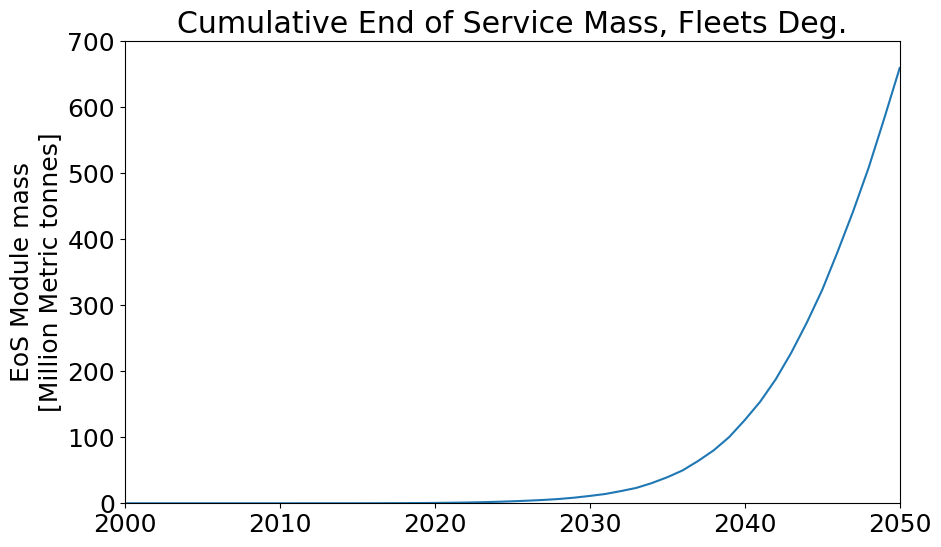

In [65]:
plt.plot(df_WasteEOL_allFleetsDegscen/1e6)
plt.ylim(0,700)
plt.xlim(2000,2050)
plt.title('Cumulative End of Service Mass, Fleets Deg.')
plt.ylabel('EoS Module mass\n[Million Metric tonnes]')

In [74]:
sim2_EoS_mats_cumu_mass = pd.DataFrame()
for mats in MATERIALS:
    sim2_EoS_mats_cumu_mass[mats+'_millionMetricTonne'] = sim2_cumu.filter(regex='WasteEOL_'+mats).sum(axis=1).loc[:2050]/1e6

#sim2_EoS_mats_cumu_mass.tail()

,glass_millionMetricTonne,silver_millionMetricTonne,silicon_millionMetricTonne,copper_millionMetricTonne,aluminium_frames_millionMetricTonne,encapsulant_millionMetricTonne,backsheet_millionMetricTonne
year,,,,,,,
2046,302.216909,0.076643,10.697339,0.219715,36.755843,21.499006,9.984531
2047,351.365080,0.086227,12.338576,0.253896,42.374003,24.809561,11.408207
2048,404.489553,0.096452,14.106604,0.290604,48.434282,28.377477,12.936466
2049,463.961854,0.108345,16.112321,0.331940,55.294677,32.422015,14.687329
2050,525.595692,0.120082,18.160369,0.374382,62.308887,36.549245,16.438206


In [78]:
df_WasteEOL_allFleetsDegscen_MMT = df_WasteEOL_allFleetsDegscen/1e6
df_WasteEOL_allFleetsDegscen_MMT.columns=['WasteEOL_Module_[million metric tonnes]']
df_WasteEOS_allFleetsDeg_Mats_MMT = pd.concat([df_WasteEOL_allFleetsDegscen_MMT, sim2_EoS_mats_cumu_mass], axis=1)
df_WasteEOS_allFleetsDeg_Mats_MMT.to_csv(os.path.join(testfolder, 'output_PVFleetsDeg_cumu_mass_mats_MMT.csv'))

In [100]:
df_areaEOS_sim2 = pd.DataFrame()
for scen in sim2.scenario.keys():
    df_areaEOS_sim2[scen] = sim2.scenario[scen].dataOut_m['Yearly_Sum_Area_atEOL']

In [106]:
df_areaEOS_sim2_all = df_areaEOS_sim2.sum(axis=1).cumsum() #sum the scens together, then cumulative area
df_areaEOS_cumu_smallModule = df_areaEOS_sim2_all/1.6
df_areaEOS_cumu_largeModule = df_areaEOS_sim2_all/2.75

df_ModulesEOS_sim2 = pd.concat([df_areaEOS_cumu_smallModule, df_areaEOS_cumu_largeModule],axis=1)
df_ModulesEOS_sim2.columns = ['Cumulative Modules 1.6m2','Cumulative Modules 2.75m2']
df_ModulesEOS_sim2.index = sim1.scenario['base'].dataIn_m['year']
df_ModulesEOS_sim2

,Cumulative Modules 1.6m2,Cumulative Modules 2.75m2
year,,
2000,0.000000e+00,0.000000e+00
2001,0.000000e+00,0.000000e+00
2002,0.000000e+00,0.000000e+00
2003,0.000000e+00,0.000000e+00
2004,8.921359e-09,5.190609e-09
...,...,...
2096,2.990099e+11,1.739694e+11
2097,3.039118e+11,1.768214e+11
2098,3.088138e+11,1.796735e+11


In [107]:
df_powerEOS_sim2 = pd.DataFrame()
for scen in sim2.scenario.keys():
    df_powerEOS_sim2[scen] = sim2.scenario[scen].dataOut_m['Yearly_Sum_Power_atEOL']

In [110]:
cumu_power_eos_sim2 = pd.Series(df_powerEOS_sim2.sum(axis=1).cumsum()/1e9) #sum the scens together, then cumulative power, in GW
cumu_power_eos_sim2.index = sim1.scenario['base'].dataIn_m['year']
cumu_power_eos_sim2

year
2000    0.000000e+00
2001    0.000000e+00
2002    0.000000e+00
2003    0.000000e+00
2004    1.839269e-15
            ...     
2096    9.641677e+04
2097    9.804608e+04
2098    9.967539e+04
2099    1.013047e+05
2100    1.029340e+05
Length: 101, dtype: float64

In [111]:
df_ModulesEOS_sim2['Cumulative Power at EoS PVFleets [GW]'] = cumu_power_eos_sim2

In [114]:
df_ModulesEOS_sim2.loc[:2050,].to_csv(os.path.join(testfolder, 'output_PVFleetsDeg_cumu_modulesAndPower.csv'))